# Notebook 01: Data Exploration based on CMIP6 Precipitation
**Rainfall Erosivity Project for Jakarta Greater Capital Region (DKI Jakarta)**

This notebook explores the raw cropped CMIP6 precipitation data produced by `crop_domain.py`.

**Models**: MRI-ESM2-0, EC-Earth3, CNRM-CM6-1  
**Scenarios**: historical, SSP1-2.6, SSP2-4.5, SSP5-8.5  
**Domain**: Jakarta bbox (lat [-7.5, -5], lon [104.125, 109.37])
**Input files**: `py/data/processed/pr_day_{model}_{scenario}_{ensemble}_jakarta.nc`

## 1. Setup & MODELS Registry

In [29]:
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as _fm
import matplotlib.cm as _cm
import matplotlib.colors as _colors

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pathlib import Path
from scipy.interpolate import RegularGridInterpolator

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# ===== Paths ====================
# notebooks/ sits two levels below project root (py/notebooks/)
PROC_DIR   = Path('../../py/data/processed')       # crop_domain.py output
CHIRPS_DIR = Path('../../py/data/bias_corrected')  # chirps_v2_jakarta_1981_2014.nc
RESULTS    = Path('../../py/results/figures')
RESULTS.mkdir(parents=True, exist_ok=True)

# ===== CMIP6 registry ====================
MODELS = {
    'MRI-ESM2-0': {
        'ensemble':  'r1i1p1f1',
        'grid':      'gn',
        'scenarios': ['historical', 'ssp126', 'ssp245', 'ssp585'],
        'color':     '#2364a5',
        'label':     'MRI-ESM2-0',
    },
    'EC-Earth3': {
        'ensemble':  'r1i1p1f1',
        'grid':      'gr',
        'scenarios': ['historical', 'ssp126', 'ssp245', 'ssp585'],
        'color':     '#e07b00',
        'label':     'EC-Earth3',
    },
    'CNRM-CM6-1': {
        'ensemble':  'r1i1p1f2',
        'grid':      'gr',
        'scenarios': ['historical', 'ssp126', 'ssp245', 'ssp585'],
        'color':     '#7b2d8b',
        'label':     'CNRM-CM6-1',
    },
}

ALL_SCENARIOS = ['historical', 'ssp126', 'ssp245', 'ssp585']
SCENARIO_LABELS = {
    'historical': 'Historical (1950–2014)',
    'ssp126':     'SSP1-2.6 (2015–2100)',
    'ssp245':     'SSP2-4.5 (2015–2100)',
    'ssp585':     'SSP5-8.5 (2015–2100)',
}
SCENARIO_COLORS = {
    'historical': '#676767',
    'ssp126':     '#2166AC',
    'ssp245':     '#4DAF4A',
    'ssp585':     '#D73027',
}

HIST_PERIOD = (1950, 2014)
NEAR_PERIOD = (2021, 2050)
FAR_PERIOD  = (2071, 2100)

# Jakarta centre at the nearest land cell in the CMIP6 grids
CENTER_LAT, CENTER_LON = -7.5, 106.875

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print('Libraries loaded ✔️')
print(f'Models   : {list(MODELS.keys())}')
print(f'Scenarios: {ALL_SCENARIOS}')

Libraries loaded ✔️
Models   : ['MRI-ESM2-0', 'EC-Earth3', 'CNRM-CM6-1']
Scenarios: ['historical', 'ssp126', 'ssp245', 'ssp585']


In [30]:
# ===== Global font settings ====================
PLOT_FONT        = 'Calibri'                     # preferred font
PLOT_FONT_ALT    = ['Arial', 'Times New Roman']  # fallback chain

_available = {f.name for f in _fm.fontManager.ttflist}
_font_to_use = PLOT_FONT if PLOT_FONT in _available else next(
    (f for f in PLOT_FONT_ALT if f in _available), 'DejaVu Sans'
)
mpl.rcParams['font.family'] = _font_to_use
mpl.rcParams['axes.titlesize']  = 11
mpl.rcParams['axes.labelsize']  = 10
mpl.rcParams['xtick.labelsize'] = 9
mpl.rcParams['ytick.labelsize'] = 9
mpl.rcParams['legend.fontsize'] = 9

print(f'Font set to: {_font_to_use}')
if _font_to_use != PLOT_FONT:
    print(f'  (Note: {PLOT_FONT!r} not found — using {_font_to_use!r} instead)')

Font set to: Calibri


### Configs

In [31]:
# ===== cftime-safe year/month extractors ====================
# Never use .time.dt.* because it breaks on 360-day and proleptic_gregorian calendars.
# Always extract via hasattr to check on the raw cftime objects.

def get_years(da: xr.DataArray) -> np.ndarray:
    t = da.time.values
    if hasattr(t[0], 'year'):
        return np.array([v.year for v in t])
    return pd.DatetimeIndex(t).year.values


def get_months(da: xr.DataArray) -> np.ndarray:
    t = da.time.values
    if hasattr(t[0], 'month'):
        return np.array([v.month for v in t])
    return pd.DatetimeIndex(t).month.values


# ===== File loader ====================
def load_pr(model: str, scenario: str, proc_dir: Path = PROC_DIR):
    """
    Load precipitation DataArray for one model × scenario.
    Returns (DataArray, Path) or (None, None) if file is missing.
    """
    cfg      = MODELS[model]
    ensemble = cfg['ensemble']
    fname    = f'pr_day_{model}_{scenario}_{ensemble}_jakarta.nc'
    fpath    = proc_dir / fname
    if not fpath.exists():
        return None, None
    ds = xr.open_dataset(fpath, decode_times=xr.coders.CFDatetimeCoder(use_cftime=True))
    pr = ds['pr']
    # Convert units if still in kg m-2 s-1
    if pr.attrs.get('units', '') in ['kg m-2 s-1', 'kg/m2/s']:
        pr = pr * 86400.0
        pr.attrs['units'] = 'mm/day'
    return pr, fpath


# ===== Spatial map helper ====================
def plot_spatial(da, title, cmap, units, output_path=None, diverging=False):
    """
    Plot a 2-D (lat × lon) DataArray as a smooth Cartopy map.

    Upsamples the coarse CMIP6 grid to 300×300 using RegularGridInterpolator
    before rendering, producing smooth continuous gradients. Uses imshow with
    the Cartopy transform for clean axis alignment.
    """
    
    # Display parameters (editable)
    MAP_FONT        = 'Calibri'                     # preferred font
    MAP_FONT_ALT    = ['Arial', 'Times New Roman']  # fallback chain
    FIG_WIDTH       = 9                             # figure width in inches
    FIG_HEIGHT      = 5                             # figure height in inches
    UPSAMPLE_N      = 300                           # interpolation grid resolution (N × N)
    COASTLINE_WIDTH = 1.0
    BORDER_WIDTH    = 0.4
    GRIDLINE_ALPHA  = 0.5
    COLORBAR_SHRINK = 0.85
    TITLE_FONTSIZE  = 11
    DPI             = 150
    OCEAN_COLOR     = '#d0e8f0'

    # Apply font preference
    _available = {f.name for f in _fm.fontManager.ttflist}
    _font = MAP_FONT if MAP_FONT in _available else next(
        (f for f in MAP_FONT_ALT if f in _available), 'DejaVu Sans'
    )
    plt.rcParams['font.family'] = _font

    lons = da.lon.values
    lats = da.lat.values
    vals = da.values.astype(float)

    # Colour scale from coarse data
    finite = vals[np.isfinite(vals)]
    if diverging:
        vmax = float(np.abs(finite).max()) if len(finite) else 1.0
        vmin_plot, vmax_plot = -vmax, vmax
    else:
        vmin_plot = float(finite.min()) if len(finite) else 0.0
        vmax_plot = float(finite.max()) if len(finite) else 1.0

    # Upsample: RegularGridInterpolator requires ascending lat axis
    lat_asc   = lats if lats[0] < lats[-1] else lats[::-1]
    vals_asc  = vals if lats[0] < lats[-1] else vals[::-1, :]

    interp = RegularGridInterpolator(
        (lat_asc, lons), vals_asc,
        method='linear',
        bounds_error=False,
        fill_value=np.nan,
    )
    lons_fine = np.linspace(lons.min(), lons.max(), UPSAMPLE_N)
    lats_fine = np.linspace(lat_asc.min(), lat_asc.max(), UPSAMPLE_N)
    grid_lon, grid_lat = np.meshgrid(lons_fine, lats_fine)
    vals_up = interp((grid_lat, grid_lon))

    fig, ax = plt.subplots(
        figsize=(FIG_WIDTH, FIG_HEIGHT),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    # OCEAN background
    ax.add_feature(cfeature.OCEAN, facecolor=OCEAN_COLOR, zorder=2)

    # Data: imshow on the upsampled array with bicubic smoothing on top
    ax.imshow(
        vals_up,
        extent=[lons.min(), lons.max(), lat_asc.min(), lat_asc.max()],
        origin='lower',
        cmap=cmap,
        vmin=vmin_plot, vmax=vmax_plot,
        interpolation='bicubic',
        transform=ccrs.PlateCarree(),
        zorder=1,
        aspect='auto',
    )

    # Dummy pcolormesh for the colorbar (imshow colorbar works but pcolormesh
    # gives a cleaner scalar mappable with the exact same vmin/vmax)
    _norm = _colors.Normalize(vmin=vmin_plot, vmax=vmax_plot)
    _sm   = plt.cm.ScalarMappable(cmap=cmap, norm=_norm)
    _sm.set_array([])
    plt.colorbar(_sm, ax=ax, label=units, shrink=COLORBAR_SHRINK, pad=0.02)

    ax.add_feature(cfeature.COASTLINE, linewidth=COASTLINE_WIDTH, zorder=5)
    ax.add_feature(cfeature.BORDERS,   linewidth=BORDER_WIDTH, linestyle=':', zorder=4)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                      alpha=GRIDLINE_ALPHA, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False

    ax.set_extent([104.125, 109.375, -7.5, -5], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight='bold')
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=DPI, bbox_inches='tight')
    return fig

print('Helpers defined ✔️')

Helpers defined ✔️


## 2. File Inventory Check

Verify that `crop_domain.py` has produced all expected files before proceeding.  
If files are missing, run:
```
python py/crop_domain/crop_domain.py --model all --scenario all
```

In [32]:
print('File inventory — processed/ directory')
print('=' * 85)

all_found  = []
all_missing = []

for model, cfg in MODELS.items():
    ensemble = cfg['ensemble']
    for scenario in cfg['scenarios']:
        fname  = f'pr_day_{model}_{scenario}_{ensemble}_jakarta.nc'
        fpath  = PROC_DIR / fname
        status = '✔️' if fpath.exists() else '❌ MISSING'
        print(f'  {status}  {model:<15} {scenario:<12} {fname}')
        if fpath.exists():
            all_found.append((model, scenario))
        else:
            all_missing.append((model, scenario))

print('=' * 85)
print(f'Found   : {len(all_found)} / {len(all_found) + len(all_missing)}')
if all_missing:
    print(f'Missing : {len(all_missing)}')
    for m, s in all_missing:
        print(f'  → {m} / {s}')
else:
    print('All files present ✔️')

File inventory — processed/ directory
  ✔️  MRI-ESM2-0      historical   pr_day_MRI-ESM2-0_historical_r1i1p1f1_jakarta.nc
  ✔️  MRI-ESM2-0      ssp126       pr_day_MRI-ESM2-0_ssp126_r1i1p1f1_jakarta.nc
  ✔️  MRI-ESM2-0      ssp245       pr_day_MRI-ESM2-0_ssp245_r1i1p1f1_jakarta.nc
  ✔️  MRI-ESM2-0      ssp585       pr_day_MRI-ESM2-0_ssp585_r1i1p1f1_jakarta.nc
  ✔️  EC-Earth3       historical   pr_day_EC-Earth3_historical_r1i1p1f1_jakarta.nc
  ✔️  EC-Earth3       ssp126       pr_day_EC-Earth3_ssp126_r1i1p1f1_jakarta.nc
  ✔️  EC-Earth3       ssp245       pr_day_EC-Earth3_ssp245_r1i1p1f1_jakarta.nc
  ✔️  EC-Earth3       ssp585       pr_day_EC-Earth3_ssp585_r1i1p1f1_jakarta.nc
  ✔️  CNRM-CM6-1      historical   pr_day_CNRM-CM6-1_historical_r1i1p1f2_jakarta.nc
  ✔️  CNRM-CM6-1      ssp126       pr_day_CNRM-CM6-1_ssp126_r1i1p1f2_jakarta.nc
  ✔️  CNRM-CM6-1      ssp245       pr_day_CNRM-CM6-1_ssp245_r1i1p1f2_jakarta.nc
  ✔️  CNRM-CM6-1      ssp585       pr_day_CNRM-CM6-1_ssp585_r1i1p1f2_jakar

## 3. Single-Model Analysis -> Historical

Load MRI-ESM2-0 historical as a representative first look at the dataset structure, coverage, and basic statistics.

In [33]:
DEMO_MODEL    = 'MRI-ESM2-0'
DEMO_SCENARIO = 'historical'

pr_demo, fpath_demo = load_pr(DEMO_MODEL, DEMO_SCENARIO)

if pr_demo is None:
    raise FileNotFoundError(
        f'File not found for {DEMO_MODEL}/{DEMO_SCENARIO}.\n'
        'Run: python py/crop_domain/crop_domain.py --model MRI-ESM2-0 --scenario historical'
    )

# ===== Basic metadata ====================
t0 = str(pr_demo.time.values[0])[:10]
t1 = str(pr_demo.time.values[-1])[:10]
years_demo = get_years(pr_demo)

print(f'Model    : {DEMO_MODEL}')
print(f'Scenario : {DEMO_SCENARIO}')
print(f'File     : {fpath_demo.name}')
print(f'Period   : {t0} → {t1}')
print(f'Years    : {int(years_demo[0])}–{int(years_demo[-1])}  ({len(np.unique(years_demo))} years)')
print(f'Days     : {len(pr_demo.time):,}')
print(f'Grid     : {len(pr_demo.lat)} lat × {len(pr_demo.lon)} lon')
print(f'Lat      : {float(pr_demo.lat.min()):.3f} → {float(pr_demo.lat.max()):.3f}')
print(f'Lon      : {float(pr_demo.lon.min()):.3f} → {float(pr_demo.lon.max()):.3f}')
print(f'Units    : {pr_demo.attrs.get("units", "mm/day")}')
print()
print('Basic statistics (spatial mean over all land cells):')
print(f'  Mean        : {float(pr_demo.mean()):.2f} mm/day')
print(f'  Std         : {float(pr_demo.std()):.2f} mm/day')
print(f'  Max         : {float(pr_demo.max()):.2f} mm/day')
print(f'  Wet-day freq: {float((pr_demo >= 1.0).mean()) * 100:.1f}%  (≥1 mm/day)')

Model    : MRI-ESM2-0
Scenario : historical
File     : pr_day_MRI-ESM2-0_historical_r1i1p1f1_jakarta.nc
Period   : 1950-01-01 → 2014-12-31
Years    : 1950–2014  (65 years)
Days     : 23,741
Grid     : 5 lat × 8 lon
Lat      : -8.411 → -3.925
Lon      : 103.500 → 111.375
Units    : mm/day

Basic statistics (spatial mean over all land cells):
  Mean        : 5.84 mm/day
  Std         : 8.31 mm/day
  Max         : 228.01 mm/day
  Wet-day freq: 57.3%  (≥1 mm/day)


In [34]:
# Inspect the full xarray Dataset structure
cfg_demo = MODELS[DEMO_MODEL]
fname_demo = f'pr_day_{DEMO_MODEL}_{DEMO_SCENARIO}_{cfg_demo["ensemble"]}_jakarta.nc'
ds_demo = xr.open_dataset(
    PROC_DIR / fname_demo,
    decode_times=xr.coders.CFDatetimeCoder(use_cftime=True)
)
print(ds_demo)

<xarray.Dataset> Size: 9MB
Dimensions:    (time: 23741, bnds: 2, lat: 5, lon: 8)
Coordinates:
  * time       (time) object 190kB 1950-01-01 12:00:00 ... 2014-12-31 12:00:00
  * lat        (lat) float64 40B -8.411 -7.29 -6.168 -5.047 -3.925
  * lon        (lon) float64 64B 103.5 104.6 105.8 106.9 108.0 109.1 110.2 111.4
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 380kB ...
    lat_bnds   (time, lat, bnds) float64 2MB ...
    lon_bnds   (time, lon, bnds) float64 3MB ...
    pr         (time, lat, lon) float32 4MB ...
Attributes: (12/51)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-05-10T01:34:30Z
    ...                     ...
    scenario:               historical
    ensemble:               r1i1p1f1
    domain:                 Jakarta Greater Capital Region
    processing:      

## 4. Spatial Maps of Mean Annual Precipitation (Historical)

One map per model, historical period. Reveals spatial gradients across the Jakarta domain.

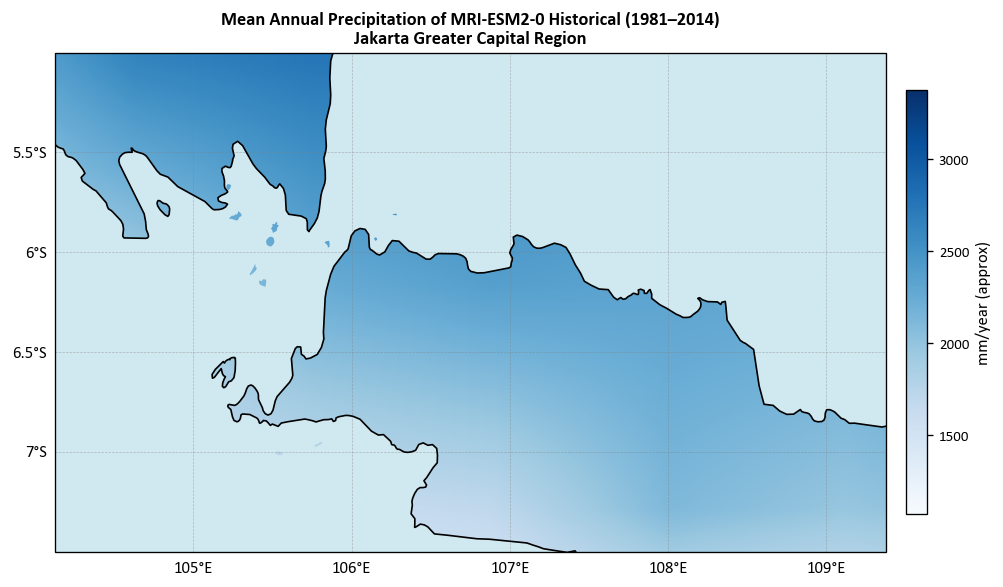

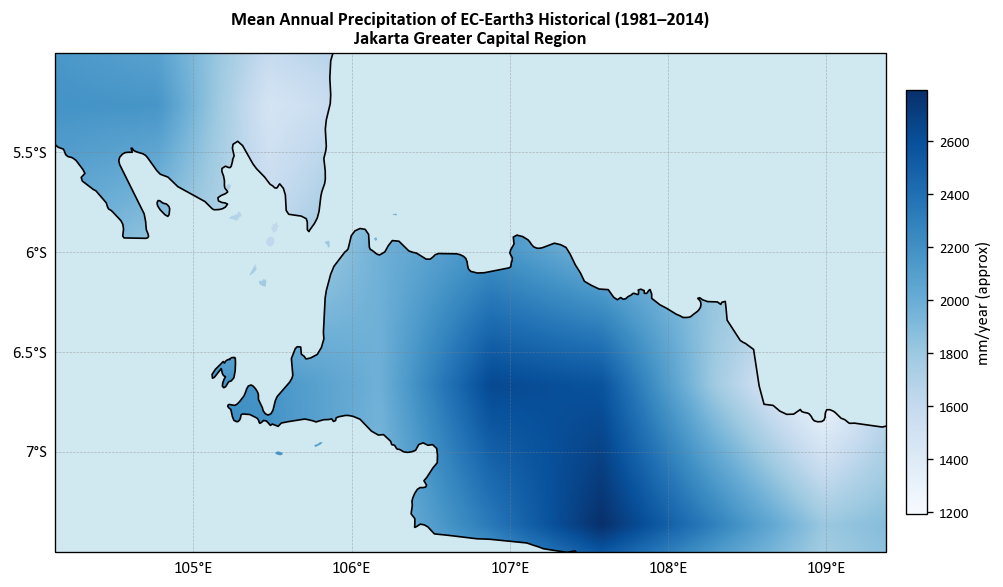

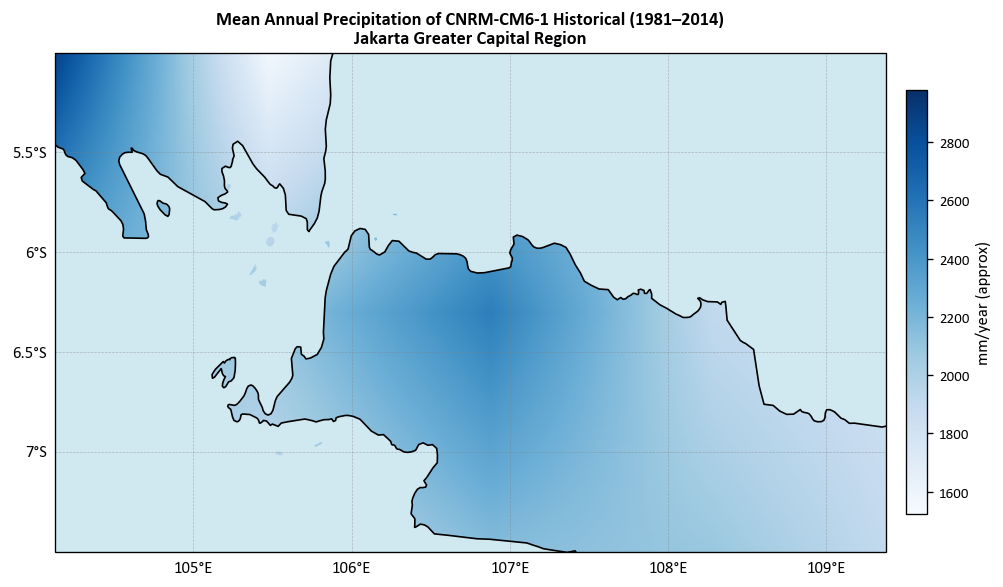

In [35]:
for model in MODELS:
    pr, fpath = load_pr(model, 'historical')
    if pr is None:
        print(f'  ⚠ Skipping {model}/historical — file not found')
        continue

    # Slice to common historical window 1981–2014 (CHIRPS calibration period)
    yrs  = get_years(pr)
    mask = (yrs >= 1981) & (yrs <= 2014)
    pr_cal = pr.isel(time=np.where(mask)[0])

    # Mean annual precipitation: daily mean × 365
    pr_annual = pr_cal.mean(dim='time') * 365

    fig = plot_spatial(
        pr_annual,
        title=f'Mean Annual Precipitation of {model} Historical (1981–2014)\n'
              f'Jakarta Greater Capital Region',
        cmap='Blues',
        units='mm/year (approx)',
        output_path=RESULTS / f'01_mean_annual_precip_{model}.png',
    )
    plt.show()

## 5. Annual Cycle of All Models × Historical

Spatial mean monthly precipitation over the Jakarta domain (1981–2014).  
Shows monsoon phase and amplitude across models, therefore key for the ensemble validation step.

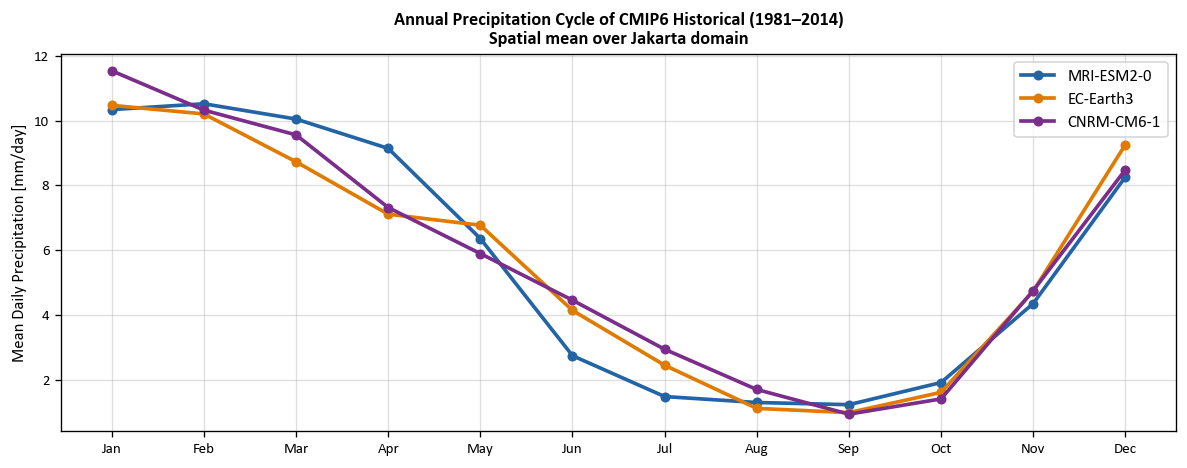


Note: Jakarta has a strongly bimodal monsoon. Wet season = Nov–Mar, dry = Jun–Sep.


In [36]:
fig, ax = plt.subplots(figsize=(10, 4))

for model, cfg in MODELS.items():
    pr, _ = load_pr(model, 'historical')

    # Slice to 1981–2014
    yrs  = get_years(pr)
    mask = (yrs >= 1981) & (yrs <= 2014)
    pr_cal = pr.isel(time=np.where(mask)[0])

    # Spatial mean, then monthly climatology
    pr_spatial = pr_cal.mean(dim=['lat', 'lon'])
    months     = get_months(pr_spatial)
    monthly    = [
        float(pr_spatial.isel(time=np.where(months == m)[0]).mean())
        for m in range(1, 13)
    ]
    ax.plot(range(12), monthly, '-o', linewidth=2.2, markersize=5,
            color=cfg['color'], label=cfg['label'])

ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Mean Daily Precipitation [mm/day]')
ax.set_title(f'Annual Precipitation Cycle of CMIP6 Historical (1981–2014)\n'
             f'Spatial mean over Jakarta domain',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS / '01_annual_cycle_models.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNote: Jakarta has a strongly bimodal monsoon. Wet season = Nov–Mar, dry = Jun–Sep.')

## 6. Multi-Model, Multi-Scenario Overview

Annual total wet-day precipitation (PRCPTOT proxy) at the Jakarta centre cell across all models and scenarios.  
Shows the full 1950–2100 record with a 10-year rolling mean.

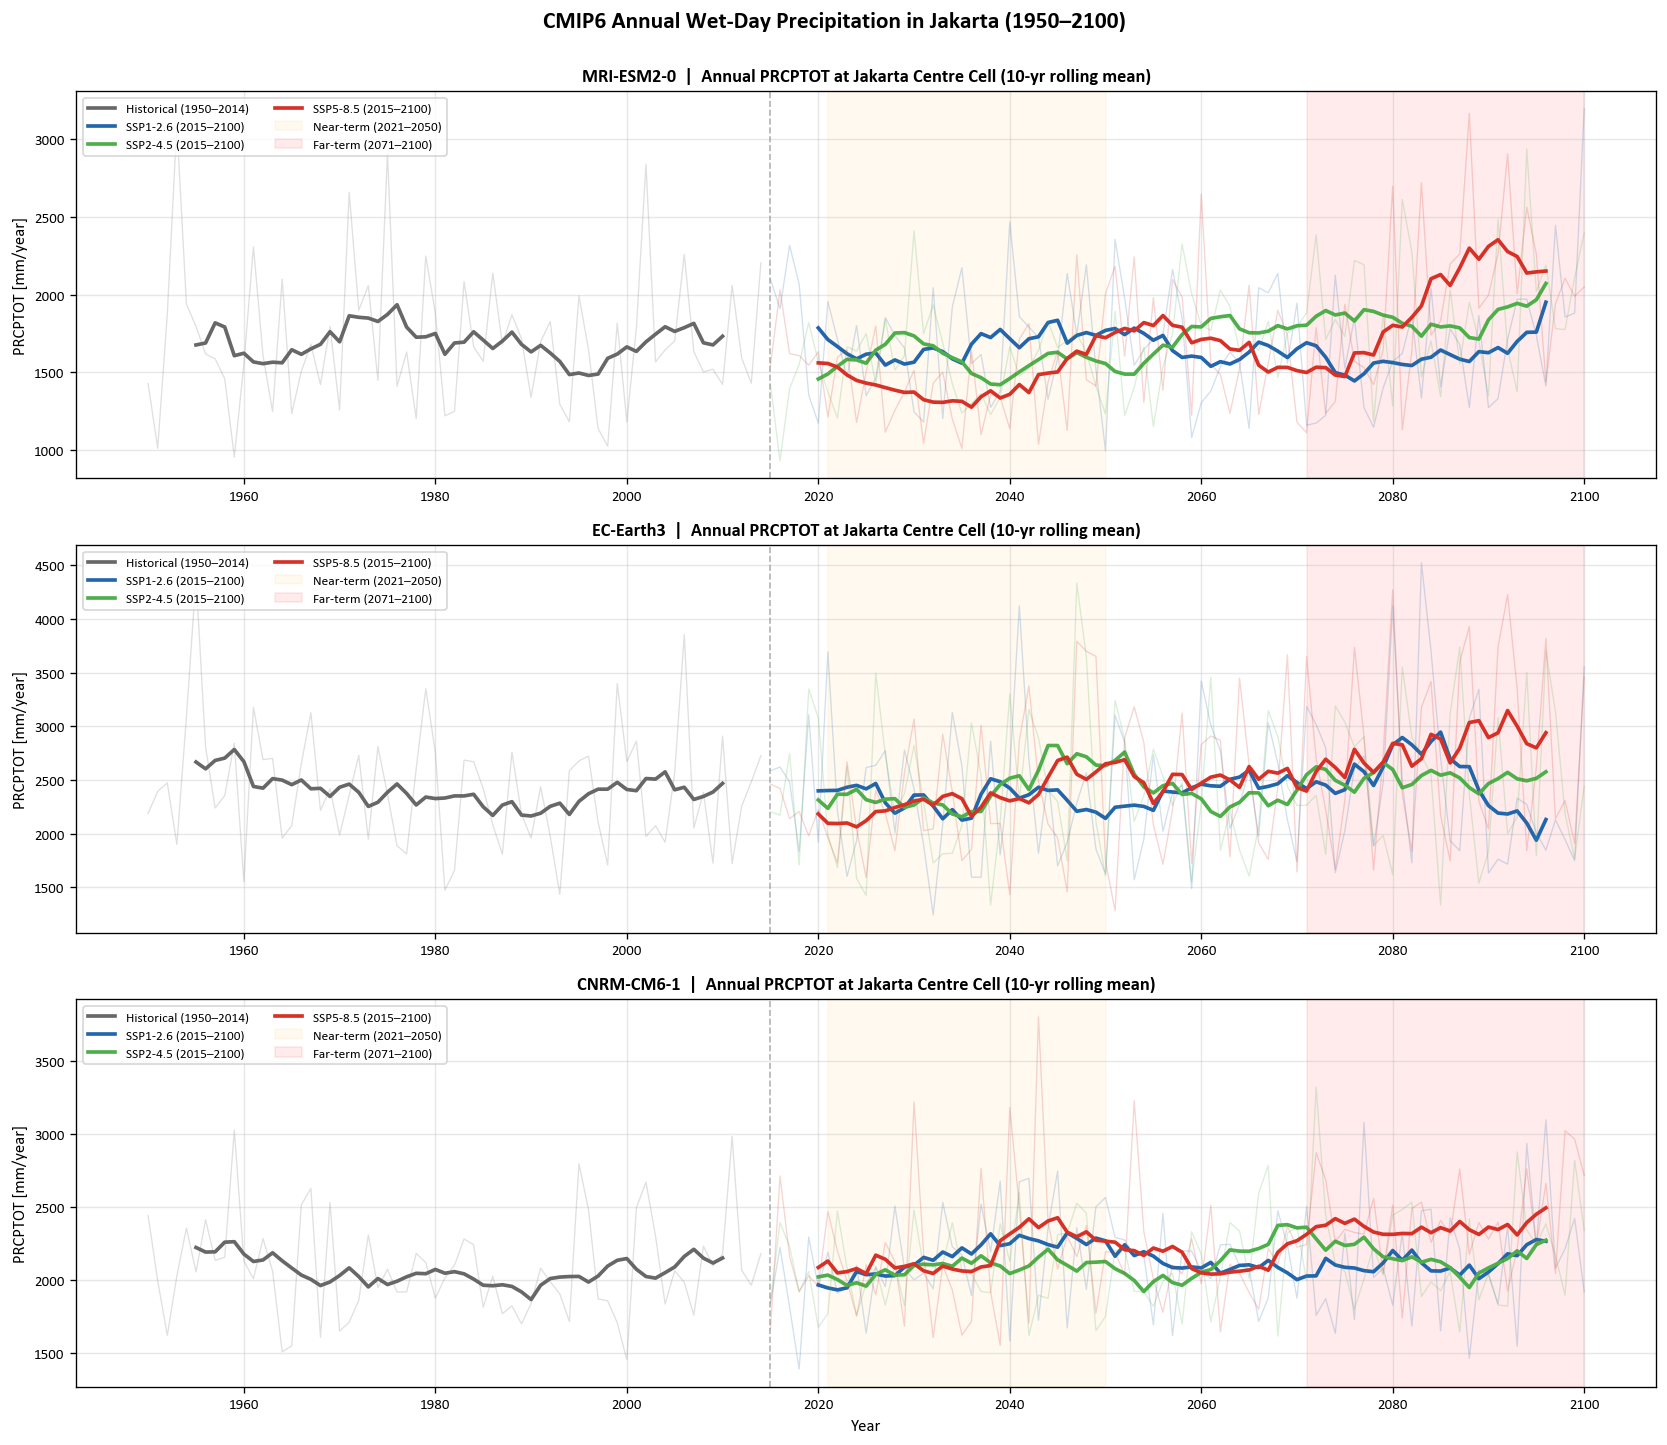

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, (model, cfg) in zip(axes, MODELS.items()):
    for scenario in ALL_SCENARIOS:
        if scenario not in cfg['scenarios']:
            continue
        pr, _ = load_pr(model, scenario)
        if pr is None:
            continue

        # Centre cell
        pr_c = pr.sel(lat=CENTER_LAT, lon=CENTER_LON, method='nearest')

        # Annual total wet-day precipitation via year-loop (cftime-safe)
        yrs         = get_years(pr_c)
        unique_yrs  = np.unique(yrs)
        annual_vals = np.array([
            float(pr_c.isel(time=np.where(yrs == yr)[0]).where(
                pr_c.isel(time=np.where(yrs == yr)[0]) >= 1.0, 0.0
            ).sum())
            for yr in unique_yrs
        ])

        roll = pd.Series(annual_vals, index=unique_yrs).rolling(10, center=True).mean()

        ax.plot(unique_yrs, annual_vals,
                alpha=0.2, color=SCENARIO_COLORS[scenario], linewidth=0.8)
        ax.plot(unique_yrs, roll.values,
                linewidth=2.2, color=SCENARIO_COLORS[scenario],
                label=SCENARIO_LABELS[scenario])

    # Shade projection periods
    ax.axvspan(*NEAR_PERIOD, alpha=0.06, color='orange', label='Near-term (2021–2050)')
    ax.axvspan(*FAR_PERIOD,  alpha=0.08, color='red',    label='Far-term (2071–2100)')
    ax.axvline(2015, color='gray', linewidth=1.0, linestyle='--', alpha=0.6)

    ax.set_title(f'{model}  |  Annual PRCPTOT at Jakarta Centre Cell (10-yr rolling mean)',
                 fontweight='bold')
    ax.set_ylabel('PRCPTOT [mm/year]')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper left', ncol=2)

axes[-1].set_xlabel('Year')
plt.suptitle('CMIP6 Annual Wet-Day Precipitation in Jakarta (1950–2100)',
             fontsize=14, fontweight='bold', y=1)
plt.tight_layout()
plt.savefig(RESULTS / '01_annual_prcptot_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# ===== Period-mean statistics table ====================
# Mean daily precipitation (spatial mean) for each model × period

period_defs = {
    'Historical (1981–2014)': (1981, 2014, 'historical'),
    'Near-term  (2021–2050)': (2021, 2050, None),  # None = any SSP
    'Far-term   (2071–2100)': (2071, 2100, None),
}

rows = []
for model, cfg in MODELS.items():
    for period_label, (yr0, yr1, fixed_scen) in period_defs.items():
        scens_to_try = [fixed_scen] if fixed_scen else ['ssp126', 'ssp245', 'ssp585']
        for scen in scens_to_try:
            if scen not in cfg['scenarios']:
                continue
            pr, _ = load_pr(model, scen)
            if pr is None:
                continue
            yrs  = get_years(pr)
            mask = (yrs >= yr0) & (yrs <= yr1)
            if mask.sum() == 0:
                continue
            pr_slice = pr.isel(time=np.where(mask)[0])
            pr_mean  = float(pr_slice.mean())
            wet_freq = float((pr_slice >= 1.0).mean()) * 100
            pr_max   = float(pr_slice.max())
            rows.append({
                'Model':       model,
                'Scenario':    SCENARIO_LABELS.get(scen, scen),
                'Period':      period_label,
                'Mean [mm/d]': round(pr_mean,  2),
                'WetFreq [%]': round(wet_freq, 1),
                'Max [mm/d]':  round(pr_max,   1),
            })
            break  # one scenario per period slot is enough for overview

df_stats = pd.DataFrame(rows)
print('Period-mean precipitation statistics:')
print(df_stats.to_string(index=False))

Period-mean precipitation statistics:
     Model               Scenario                 Period  Mean [mm/d]  WetFreq [%]  Max [mm/d]
MRI-ESM2-0 Historical (1950–2014) Historical (1981–2014)         5.62         55.9       156.6
MRI-ESM2-0   SSP1-2.6 (2015–2100) Near-term  (2021–2050)         5.50         52.5       152.5
MRI-ESM2-0   SSP1-2.6 (2015–2100) Far-term   (2071–2100)         5.51         51.4       175.7
 EC-Earth3 Historical (1950–2014) Historical (1981–2014)         5.62         61.1       114.0
 EC-Earth3   SSP1-2.6 (2015–2100) Near-term  (2021–2050)         5.66         61.6        99.8
 EC-Earth3   SSP1-2.6 (2015–2100) Far-term   (2071–2100)         6.05         64.1       102.2
CNRM-CM6-1 Historical (1950–2014) Historical (1981–2014)         5.76         52.7       135.0
CNRM-CM6-1   SSP1-2.6 (2015–2100) Near-term  (2021–2050)         5.97         52.2       135.1
CNRM-CM6-1   SSP1-2.6 (2015–2100) Far-term   (2071–2100)         6.00         51.9       120.3


## 7. Extreme Rainfall & Flood Threshold Exceedances

Jakarta flood thresholds: 100 mm/day (moderate), 150 mm/day (severe), 200 mm/day (extreme).  
Exceedance frequency at the centre cell across models and scenarios.

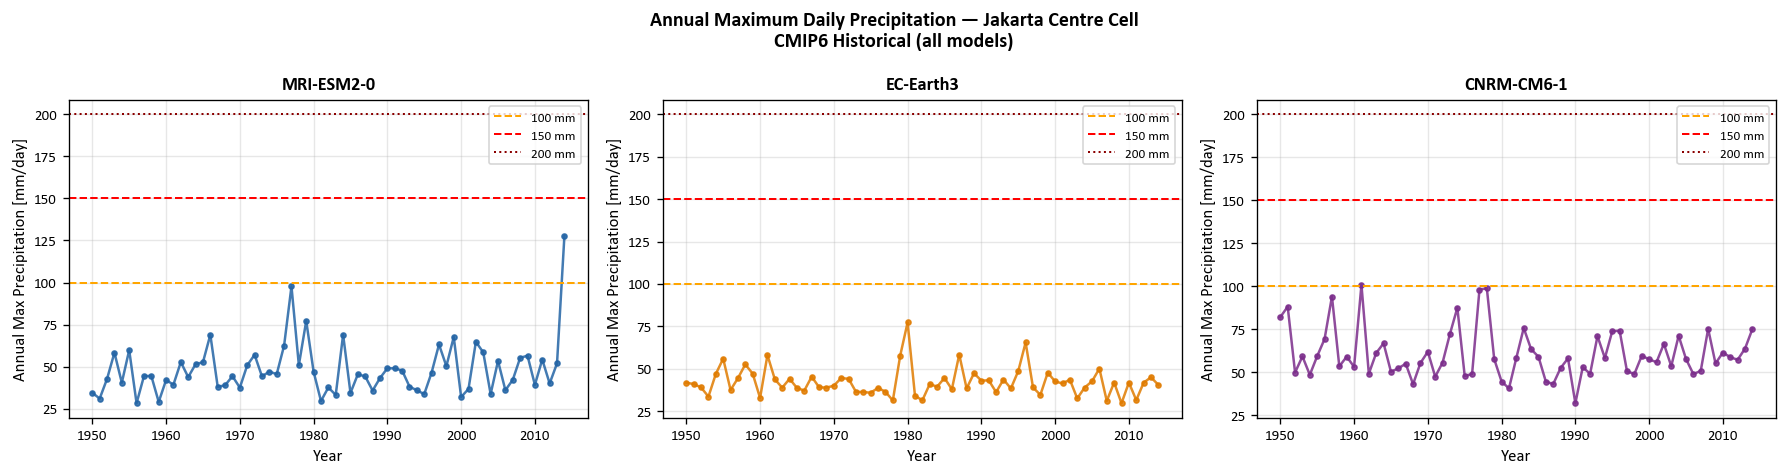

In [39]:
# ===== Annual maximum daily precipitation of all models, historical ====================
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (model, cfg) in zip(axes, MODELS.items()):
    pr, _ = load_pr(model, 'historical')
    if pr is None:
        ax.set_title(f'{model}\n(file missing)')
        continue

    pr_c   = pr.sel(lat=CENTER_LAT, lon=CENTER_LON, method='nearest')
    yrs    = get_years(pr_c)
    u_yrs  = np.unique(yrs)
    ann_max = np.array([
        float(pr_c.isel(time=np.where(yrs == yr)[0]).max())
        for yr in u_yrs
    ])

    ax.plot(u_yrs, ann_max, '-o', color=cfg['color'],
            linewidth=1.5, markersize=3, alpha=0.85)
    ax.axhline(100, color='orange', linestyle='--', linewidth=1.2, label='100 mm')
    ax.axhline(150, color='red',    linestyle='--', linewidth=1.2, label='150 mm')
    ax.axhline(200, color='darkred',linestyle=':',  linewidth=1.2, label='200 mm')
    ax.set_title(f'{model}', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Annual Max Precipitation [mm/day]')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Annual Maximum Daily Precipitation — Jakarta Centre Cell\nCMIP6 Historical (all models)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / '01_annual_maxima_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

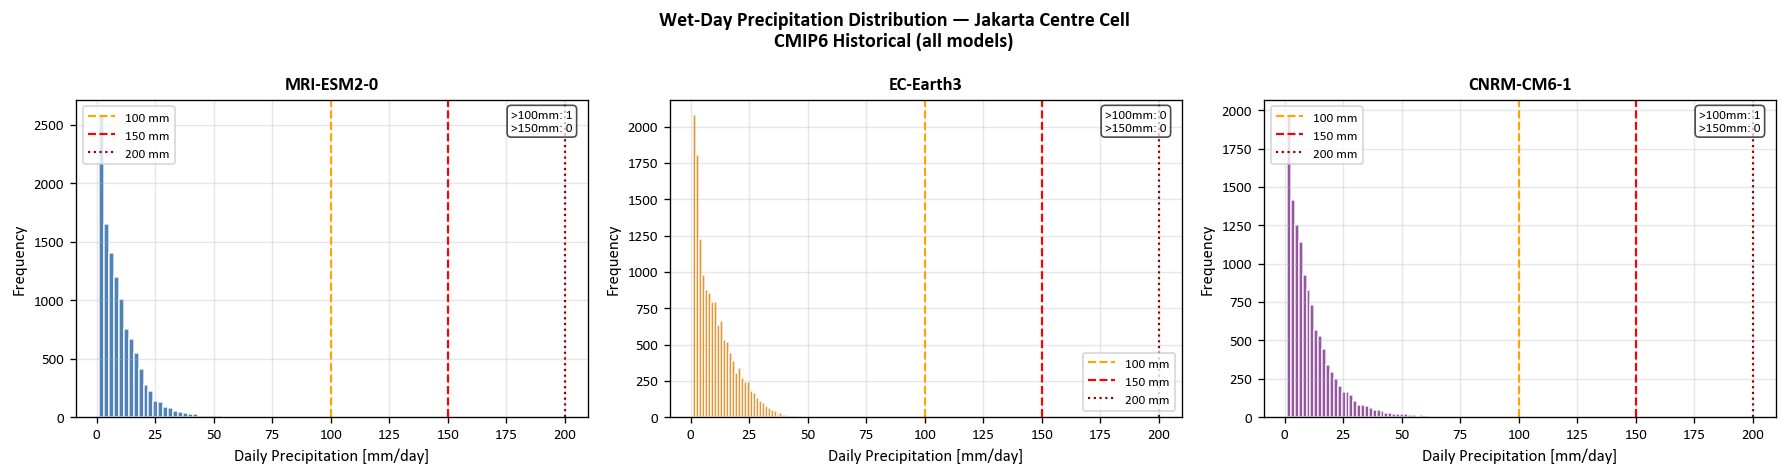

In [40]:
# ===== Wet-day precipitation distribution of all models ====================
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (model, cfg) in zip(axes, MODELS.items()):
    pr, _ = load_pr(model, 'historical')
    if pr is None:
        ax.set_title(f'{model}\n(file missing)')
        continue

    pr_c    = pr.sel(lat=CENTER_LAT, lon=CENTER_LON, method='nearest')
    pr_flat = pr_c.values.astype(float)
    pr_wet  = pr_flat[pr_flat >= 1.0]

    ax.hist(pr_wet, bins=60, color=cfg['color'], edgecolor='white', alpha=0.8)
    ax.axvline(100, color='orange', linestyle='--', linewidth=1.3, label='100 mm')
    ax.axvline(150, color='red',    linestyle='--', linewidth=1.3, label='150 mm')
    ax.axvline(200, color='darkred',linestyle=':',  linewidth=1.3, label='200 mm')
    ax.set_title(f'{model}', fontweight='bold')
    ax.set_xlabel('Daily Precipitation [mm/day]')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    n100 = int((pr_wet >= 100).sum())
    n150 = int((pr_wet >= 150).sum())
    ax.text(0.97, 0.97, f'>100mm: {n100}\n>150mm: {n150}',
            transform=ax.transAxes, va='top', ha='right',
            fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('Wet-Day Precipitation Distribution — Jakarta Centre Cell\nCMIP6 Historical (all models)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / '01_wetday_distribution_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# ===== Flood threshold exceedance summary ====================
thresholds = {
    'Moderate (100 mm)': 100.0,
    'Severe   (150 mm)': 150.0,
    'Extreme  (200 mm)': 200.0,
}

rows = []
for model, cfg in MODELS.items():
    for scenario in ALL_SCENARIOS:
        if scenario not in cfg['scenarios']:
            continue
        pr, _ = load_pr(model, scenario)
        if pr is None:
            continue

        pr_c    = pr.sel(lat=CENTER_LAT, lon=CENTER_LON, method='nearest')
        pr_vals = pr_c.values.astype(float)
        n_total = len(pr_vals)
        row     = {'Model': model, 'Scenario': SCENARIO_LABELS.get(scenario, scenario)}
        for label, thresh in thresholds.items():
            n_exceed      = int((pr_vals >= thresh).sum())
            pct           = n_exceed / n_total * 100
            row[f'{label} (n)']   = n_exceed
            row[f'{label} (%)']   = round(pct, 3)
        rows.append(row)

df_exc = pd.DataFrame(rows)
print('Jakarta Flood Threshold Exceedances for Jakarta Centre Cell')
print(df_exc.to_string(index=False))

Jakarta Flood Threshold Exceedances for Jakarta Centre Cell
     Model               Scenario  Moderate (100 mm) (n)  Moderate (100 mm) (%)  Severe   (150 mm) (n)  Severe   (150 mm) (%)  Extreme  (200 mm) (n)  Extreme  (200 mm) (%)
MRI-ESM2-0 Historical (1950–2014)                      1                  0.004                      0                  0.000                      0                  0.000
MRI-ESM2-0   SSP1-2.6 (2015–2100)                      1                  0.003                      1                  0.003                      1                  0.003
MRI-ESM2-0   SSP2-4.5 (2015–2100)                      2                  0.006                      1                  0.003                      0                  0.000
MRI-ESM2-0   SSP5-8.5 (2015–2100)                      3                  0.010                      1                  0.003                      0                  0.000
 EC-Earth3 Historical (1950–2014)                      0                  0.000 

## 8. CHIRPS Reference Overview

Quick look at the CHIRPS v2.0 observational reference used for QDM bias correction.  
File: `chirps_v2_jakarta_1981_2014.nc`, produced by `QDM.py prepare`.

CHIRPS file : chirps_v2_jakarta_1981_2014.nc
Period      : 1981-01-01 → 2014-12-31
Days        : 12,418
Grid        : 26 lat × 44 lon
Mean        : 7.20 mm/day
Wet-day freq: 17.7%
Max         : 217.3 mm/day


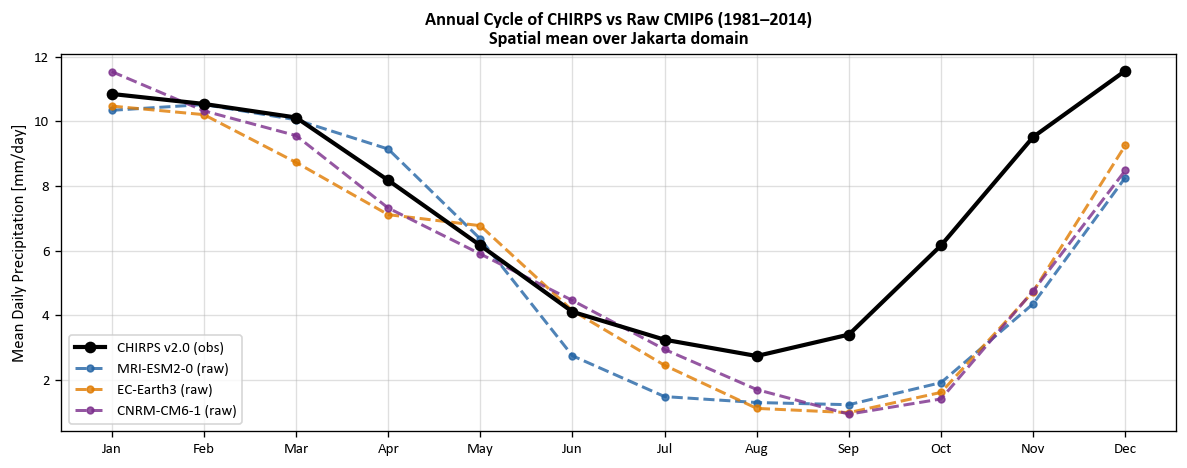

In [42]:
chirps_file = next(CHIRPS_DIR.glob('chirps_v2_jakarta_*.nc'), None)

if chirps_file is None:
    print('⚠ CHIRPS file not found in bias_corrected/.')
    print('  Run: python py/bias_correction/QDM.py prepare')
else:
    ds_chirps = xr.open_dataset(
        chirps_file,
        decode_times=xr.coders.CFDatetimeCoder(use_cftime=True)
    )
    # CHIRPS uses 'precip'; normalise to 'pr'
    if 'precip' in ds_chirps and 'pr' not in ds_chirps:
        ds_chirps = ds_chirps.rename({'precip': 'pr'})
    pr_chirps = ds_chirps['pr']

    t0 = str(pr_chirps.time.values[0])[:10]
    t1 = str(pr_chirps.time.values[-1])[:10]
    print(f'CHIRPS file : {chirps_file.name}')
    print(f'Period      : {t0} → {t1}')
    print(f'Days        : {len(pr_chirps.time):,}')
    print(f'Grid        : {len(pr_chirps.lat)} lat × {len(pr_chirps.lon)} lon')
    print(f'Mean        : {float(pr_chirps.mean()):.2f} mm/day')
    print(f'Wet-day freq: {float((pr_chirps >= 1.0).mean()) * 100:.1f}%')
    print(f'Max         : {float(pr_chirps.max()):.1f} mm/day')

    # Annual cycle of CHIRPS vs all models (historical 1981–2014)
    fig, ax = plt.subplots(figsize=(10, 4))

    pr_c_spatial = pr_chirps.mean(dim=['lat', 'lon'])
    months_c     = get_months(pr_c_spatial)
    monthly_c    = [float(pr_c_spatial.isel(time=np.where(months_c == m)[0]).mean())
                    for m in range(1, 13)]
    ax.plot(range(12), monthly_c, '-o', linewidth=2.5, markersize=6,
            color='black', label='CHIRPS v2.0 (obs)', zorder=5)

    for model, cfg in MODELS.items():
        pr_m, _ = load_pr(model, 'historical')
        if pr_m is None:
            continue
        yrs_m  = get_years(pr_m)
        mask_m = (yrs_m >= 1981) & (yrs_m <= 2014)
        pr_ms  = pr_m.isel(time=np.where(mask_m)[0]).mean(dim=['lat', 'lon'])
        months_m = get_months(pr_ms)
        monthly_m = [float(pr_ms.isel(time=np.where(months_m == mo)[0]).mean())
                     for mo in range(1, 13)]
        ax.plot(range(12), monthly_m, '--o', linewidth=1.8, markersize=4,
                color=cfg['color'], label=f'{model} (raw)', alpha=0.8)

    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_NAMES)
    ax.set_ylabel('Mean Daily Precipitation [mm/day]')
    ax.set_title(f'Annual Cycle of CHIRPS vs Raw CMIP6 (1981–2014)\n'
                 f'Spatial mean over Jakarta domain',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(RESULTS / '01_annual_cycle_chirps_vs_models.png', dpi=150, bbox_inches='tight')
    plt.show()

    ds_chirps.close()

## ✅ Summary

**Data confirmed:**
- Three CMIP6 models (MRI-ESM2-0, EC-Earth3, CNRM-CM6-1) across four scenarios (historical, SSP1-2.6, SSP2-4.5, SSP5-8.5)
- All files cropped to the Jakarta bbox (lat [-7.5, -5], lon [104.125, 109.375]), units in mm/day
- cftime calendars preserved, which means all resampling done via explicit year/month loops

**Key findings from raw data:**
- Jakarta's monsoon structure is visible across all models (wet Nov–Mar, dry Jun–Sep)
- All CMIP6 models show systematic wet biases vs CHIRPS, therefore consistent with known convective parameterisation issues over maritime Southeast Asia
- Bias correction (QDM, Notebook 02) is needed before index computation

**Next:** `02_QDM.ipynb` -> QDM application and validation